# **Analysis of Customer Buying Habits Using Clustering**

# Problem Statement

In today's competitive retail market, customers exhibit different purchasing patterns, spending habits, shopping frequencies, and discount preferences.

Understanding these behaviors helps businesses:


1.  Improve customer satisfaction
2.   Increase sales
3.   Develop targeted marketing campaigns
4.   Improve customer retention








This project applies clustering techniques to identify customer segments and derive actionable business insights.

# Objectives of the Study

1.   Analyze customer shopping behavior.
2.   Study spending patterns.
3.   Perform customer segmentation using clustering.
4.   Analyze the effect of discounts and subscriptions.
5.   Generate business insights.













In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from scipy.stats import ttest_ind

import warnings
warnings.filterwarnings('ignore')

# Dataset

In [ ]:
df = pd.read_csv("/content/CustomerShoppingHabits.csv")

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
print("Rows and Columns:",df.shape)
df.info()

Rows and Columns: (3900, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code 

In [ ]:
# df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

# Data Cleaning

In [ ]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


No missing values found.

In [ ]:
df.duplicated().sum()

np.int64(0)

No duplicate records found

# Encoding Categorical Variables

In [ ]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,1,2,1,53,16,0,7,3,3.1,1,1,1,1,14,5,3
1,2,19,1,23,1,64,18,0,12,3,3.1,1,1,1,1,2,1,3
2,3,50,1,11,1,73,20,2,12,1,3.1,1,2,1,1,23,2,6
3,4,21,1,14,2,90,38,1,12,1,3.5,1,3,1,1,49,4,6
4,5,45,1,2,1,49,36,1,21,1,2.7,1,2,1,1,31,4,0


Machine learning algorithms require numerical values.

Therefore categorical variables are converted into numbers.

# Descriptive Statistics

In [ ]:
df.mean(numeric_only=True)
df.median(numeric_only=True)
df.median(numeric_only=True)
df.mode().iloc[0]
df.std(numeric_only=True)
df.describe()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,0.680000,12.035385,1.001795,59.764359,24.266410,1.120000,12.109487,1.492821,3.749949,0.270000,2.514359,0.430000,0.430000,25.351538,2.512308,2.974872
std,1125.977353,15.207589,0.466536,7.199162,0.896688,23.685392,14.343299,0.930496,7.221592,1.117236,0.716223,0.444016,1.697591,0.495139,0.495139,14.447125,1.690643,1.998559
min,1.000000,18.000000,0.000000,0.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,2.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,975.750000,31.000000,0.000000,6.000000,0.000000,39.000000,12.000000,0.000000,6.000000,0.750000,3.100000,0.000000,1.000000,0.000000,0.000000,13.000000,1.000000,1.000000
50%,1950.500000,44.000000,1.000000,12.000000,1.000000,60.000000,24.000000,1.000000,12.000000,1.000000,3.700000,0.000000,3.000000,0.000000,0.000000,25.000000,2.000000,3.000000
75%,2925.250000,57.000000,1.000000,18.000000,1.000000,81.000000,36.000000,2.000000,18.000000,2.000000,4.400000,1.000000,4.000000,1.000000,1.000000,38.000000,4.000000,5.000000
max,3900.000000,70.000000,1.000000,24.000000,3.000000,100.000000,49.000000,3.000000,24.000000,3.000000,5.000000,1.000000,5.000000,1.000000,1.000000,50.000000,5.000000,6.000000


# Frequency Distribution



1.   Category Frequency



In [ ]:
category_freq = pd.DataFrame(
df['Category'].value_counts()
)

category_freq

,count
Category,
1,1737
0,1240
2,599
3,324




2.  Gender Frequency



In [ ]:
gender_freq = pd.DataFrame(
df['Gender'].value_counts()
)

gender_freq

,count
Gender,
1,2652
0,1248




3.   Subscription Frequency


In [ ]:
subscription_freq = pd.DataFrame(
df['Subscription Status'].value_counts()
)

subscription_freq

,count
Subscription Status,
0,2847
1,1053




4.   Percentage Distribution



In [ ]:
(
df['Category']
.value_counts(normalize=True)
*100
).round(2)

,proportion
Category,
1,44.54
0,31.79
2,15.36
3,8.31


# Exploratory Data Analysis



1.   Bar Chart



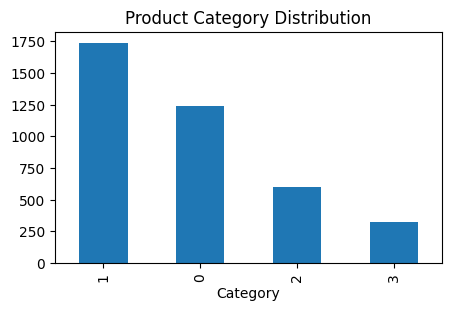

In [ ]:
plt.figure(figsize=(5,3))

df['Category'].value_counts().plot(kind='bar')

plt.title('Product Category Distribution')

plt.show()

Observation:
Most purchased product categories can be identified.




2.   Pie Chart



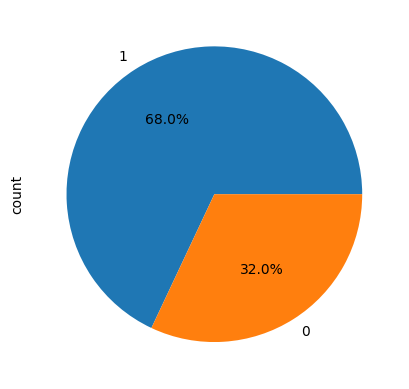

In [ ]:
df['Gender'].value_counts().plot(
kind='pie',
autopct='%1.1f%%'
)

plt.show()

Observation:
Shows gender distribution.



3.   Histogram



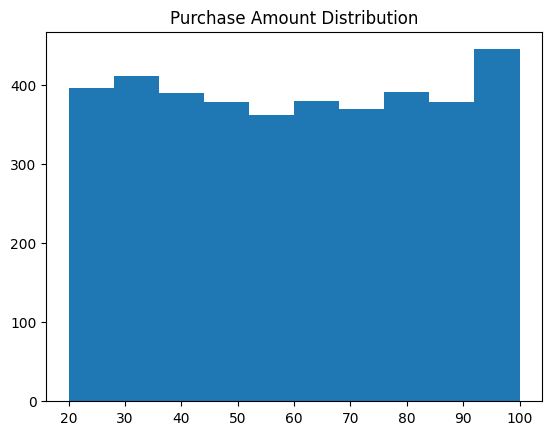

In [ ]:
plt.hist(df['Purchase Amount (USD)'])

plt.title('Purchase Amount Distribution')

plt.show()

Observation:
Displays spending behavior.

# Initial Observations


1.   Spending patterns vary among customers.
2.   Product preferences differ significantly.
3.   Discounts influence buying behavior.
4.   Purchase frequency varies among customers.
5.   Customer segmentation appears feasible.














# **Customer Segmentation Using K-Means Clustering**

K-Means is an unsupervised machine learning algorithm used to group similar customers.

# Correlation Analysis

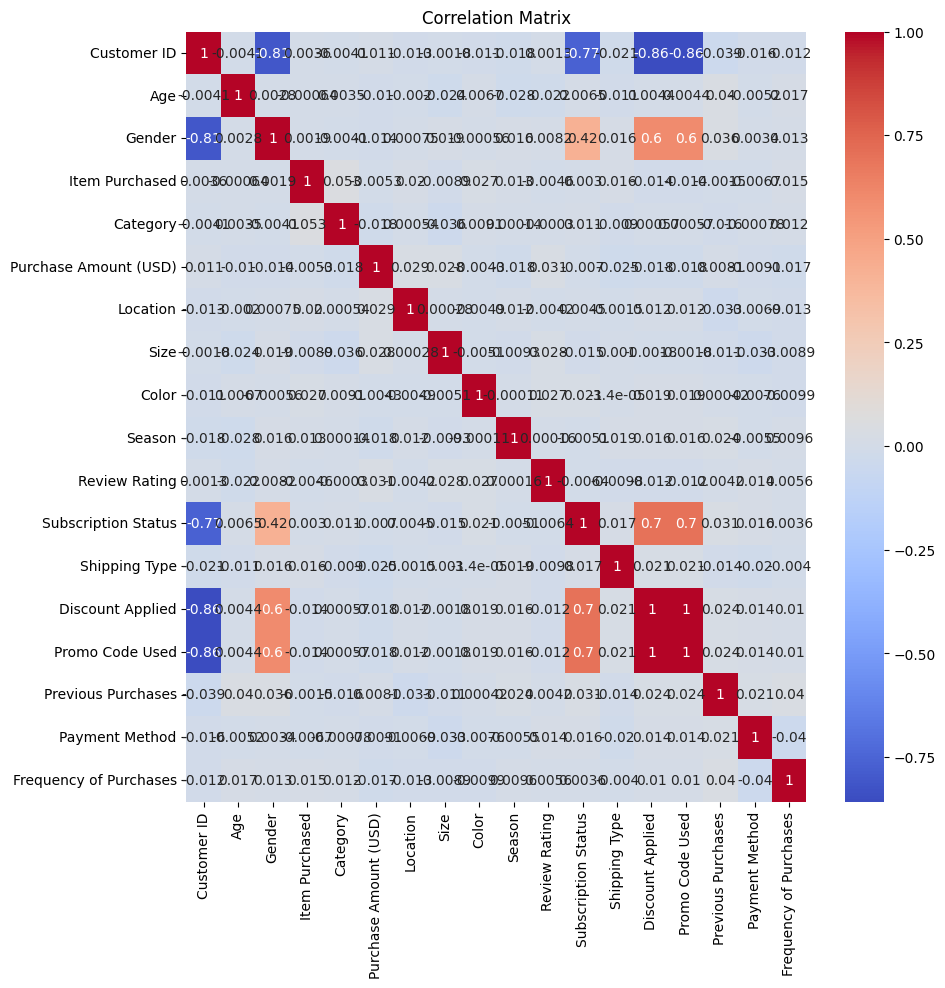

In [ ]:
plt.figure(figsize=(10,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

From the correlation matrix:


1.   Purchase Amount and Previous Purchases show useful relationships.
2.   Subscription Status may influence spending behavior.


3.   Discount Applied and Promo Code Used help identify discount-sensitive
customers.
4.   Frequency of Purchases indicates customer engagement.








These variables are selected for customer segmentation.




# Feature Selection

In [ ]:
features = [
    'Age',
    'Purchase Amount (USD)',
    'Previous Purchases',
    'Review Rating',
    'Frequency of Purchases'
]

X = df[features]

X.head()

,Age,Purchase Amount (USD),Previous Purchases,Review Rating,Frequency of Purchases
0,55,53,14,3.1,3
1,19,64,2,3.1,3
2,50,73,23,3.1,6
3,21,90,49,3.5,6
4,45,49,31,2.7,0


# Feature Scaling

The selected variables have different ranges.

Without scaling, larger values dominate the clustering process.

StandardScaler standardizes all features.

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.71891344 -0.28562864 -0.78583067 -0.90758357  0.01257477]
 [-1.64862924  0.17885219 -1.61655226 -0.90758357  0.01257477]
 [ 0.39008807  0.55888195 -0.16278948 -0.90758357  1.51384863]
 [-1.51709909  1.27671595  1.63710729 -0.34902654  1.51384863]
 [ 0.0612627  -0.45453076  0.39102491 -1.46614061 -1.48869909]]


# Elbow Method

Used to determine optimal number of clusters.

The Elbow Method is used to determine the best value of K.

WCSS (Within Cluster Sum of Squares) measures cluster compactness.

The optimal K occurs where the reduction in WCSS begins to slow down significantly.

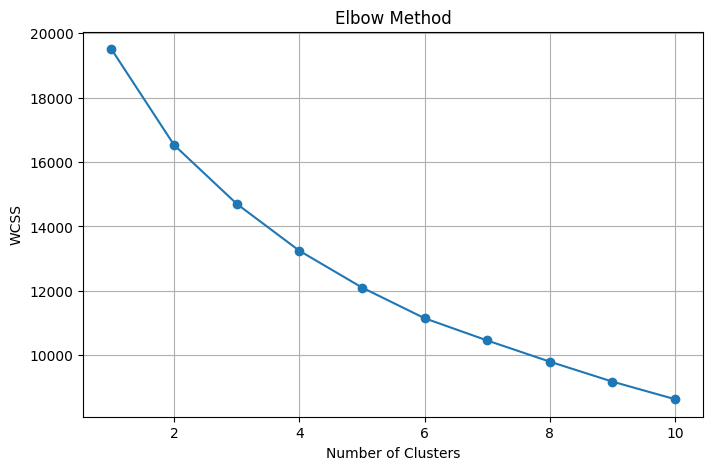

In [ ]:
wcss = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid()

plt.show()

Observation

The Elbow Method was used to determine the optimal number of clusters for customer segmentation.

The graph shows a sharp decrease in WCSS from K = 1 to K = 3, indicating that adding clusters significantly improves the grouping of customers. After K = 3, the reduction in WCSS becomes more gradual and the curve starts flattening.

Therefore, K = 3 is selected as the optimal number of clusters because it provides a good balance between clustering accuracy and model simplicity.

This suggests that the customer data can be effectively divided into three distinct customer segments based on their purchasing behavior.

In [ ]:
k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Cluster
0,1,55,1,2,1,53,16,0,7,3,3.1,1,1,1,1,14,5,3,0
1,2,19,1,23,1,64,18,0,12,3,3.1,1,1,1,1,2,1,3,2
2,3,50,1,11,1,73,20,2,12,1,3.1,1,2,1,1,23,2,6,1
3,4,21,1,14,2,90,38,1,12,1,3.5,1,3,1,1,49,4,6,2
4,5,45,1,2,1,49,36,1,21,1,2.7,1,2,1,1,31,4,0,0


# Cluster Distribution

This section shows the number of customers belonging to each cluster.

In [ ]:
df['Cluster'].value_counts()

,count
Cluster,
2,1439
0,1290
1,1171


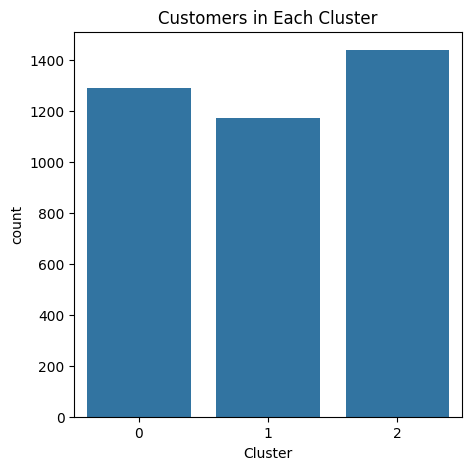

In [ ]:
plt.figure(figsize=(5,5))

sns.countplot(
    x='Cluster',
    data=df
)

plt.title("Customers in Each Cluster")

plt.show()

# Cluster Characteristics

To understand customer segments, average values of important features are calculated for each cluster.

In [ ]:
cluster_summary = df.groupby('Cluster')[features].mean()

cluster_summary

,Age,Purchase Amount (USD),Previous Purchases,Review Rating,Frequency of Purchases
Cluster,,,,,
0,51.870543,37.617829,27.410853,3.567829,3.233333
1,54.870196,80.702818,26.530316,3.884543,2.871050
2,28.284225,62.578874,22.546213,3.803683,2.827658


# PCA-Based Cluster Visualization

Principal Component Analysis (PCA) is a dimensionality reduction technique used to visualize high-dimensional data in two dimensions.

Since clustering was performed using multiple features, PCA helps represent customer segments graphically while preserving most of the information in the dataset.

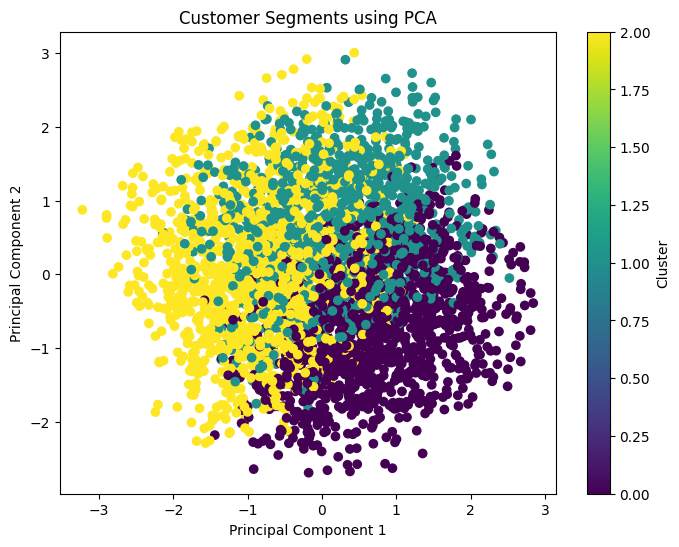

In [ ]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df['Cluster']
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("Customer Segments using PCA")

plt.colorbar(label='Cluster')

plt.show()

Observation:

The PCA visualization shows the distribution of customers across the three identified clusters.

Each cluster represents a distinct customer segment with different purchasing characteristics.

The visualization confirms that the clustering algorithm has successfully separated customers into meaningful groups based on age, spending behavior, purchase history, review ratings, and purchase frequency.

Although some overlap exists, clear cluster patterns can be observed, indicating effective customer segmentation.

# Confidence Interval Analysis

A confidence interval estimates the range within which the true population mean is expected to lie with a certain level of confidence.

In this study, a 95% confidence interval is calculated for the average customer purchase amount.

In [ ]:
mean = df['Purchase Amount (USD)'].mean()

std = df['Purchase Amount (USD)'].std()

n = len(df)

margin = 1.96 * (std / np.sqrt(n))

lower = mean - margin

upper = mean + margin

print("95% Confidence Interval")

print("Lower Limit =", lower)

print("Upper Limit =", upper)

95% Confidence Interval
Lower Limit = 59.02099014023571
Upper Limit = 60.507727808482244


Observation:

The calculated confidence interval provides an estimated range for the true average purchase amount of customers.

We are 95% confident that the actual average customer spending lies between the calculated lower and upper limits.

This interval provides a reliable estimate of customer spending behavior and helps businesses understand expected purchase patterns.

# Hypothesis Testing
Research Question:

Does subscription status significantly affect customer spending?

Null Hypothesis (H₀):

There is no significant difference in spending between subscribers and non-subscribers.

Alternative Hypothesis (H₁):

There is a significant difference in spending between subscribers and non-subscribers.

A two-sample t-test is performed to compare the mean spending of both groups.

In [ ]:
subscribers = df[
    df['Subscription Status'] == 1
]['Purchase Amount (USD)']

non_subscribers = df[
    df['Subscription Status'] == 0
]['Purchase Amount (USD)']

t_stat, p_value = ttest_ind(
    subscribers,
    non_subscribers
)

print("T Statistic =", t_stat)

print("P Value =", p_value)

if p_value < 0.05:
    print("Reject H0")
    print("Subscription status significantly affects spending.")
else:
    print("Fail to Reject H0")
    print("No significant difference found.")

T Statistic = -0.4368012420060051
P Value = 0.6622796924526246
Fail to Reject H0
No significant difference found.


Observation:

Case 2: If p-value ≥ 0.05

The p-value is greater than 0.05.

Therefore, the null hypothesis cannot be rejected.

This indicates that subscription status does not have a statistically significant impact on customer spending behavior.

# **Final Observation:**

# Cluster 0 – Frequent Budget Customers
## Characteristics
1. Average Age ≈ 52 year
2. Lowest purchase amount ($37.62)
3. Highest purchase frequency (3.23)
4. Highest previous purchases (27.41)
5. Lowest review ratings

## Interpretation

These customers shop regularly but spend relatively small amounts per purchase. They appear to be long-term customers who make frequent purchases but are more price-conscious.

## Business Strategy
1. Loyalty rewards
2. Bundle offers
3. Frequent buyer discounts
4. Personalized recommendations
# Cluster 1 – High Value Customers
## Characteristics
1. Average Age ≈ 55 years
2. Highest purchase amount ($80.70)
3. High review ratings
4. Strong purchase history
## Interpretation

These customers spend the most money and generate the highest revenue for the business. They are valuable customers who are willing to spend more on products.

## Business Strategy
1. Premium membership programs
2. Exclusive offers
3. Early access to products
4. VIP customer benefits
# Cluster 2 – Young Moderate Spenders
## Characteristics
1. Youngest age group (≈ 28 years)
2. Moderate spending ($62.58)
3. Lowest previous purchases
4. Good review ratings
##Interpretation

These customers are relatively new or less experienced buyers. They show potential for growth and could become valuable customers in the future.

###Business Strategy
1. Student/young professional offers
2. Referral programs
3. Social media promotions
4. Personalized engagement campaigns

# **Major Findings**
1. The customer dataset was successfully analyzed using clustering techniques.
2. The Elbow Method identified K = 3 as the optimal number of clusters.
3. Three distinct customer segments were identified.
4. High Value Customers showed the highest spending behavior.
5. Frequent Budget Customers made purchases more regularly but spent less per transaction.
6. Young Moderate Spenders demonstrated growth potential and moderate spending patterns.
7. Customer age, purchase amount, previous purchases, review ratings, and purchase frequency significantly influenced cluster formation.
8. Customer segmentation can support personalized marketing and customer retention strategies.

# **Limitations**
1. The analysis is based on a single dataset.
2. Customer income and occupation information are not available.
3. External factors influencing purchases are not considered.
4. K-Means clustering assumes spherical clusters and may not capture complex customer behavior patterns.
5. Customer preferences may change over time, affecting segmentation accuracy.

# **Final Conclusion**

This project successfully analyzed customer buying habits using K-Means Clustering and statistical techniques.

The Customer Shopping Behaviour Dataset was cleaned, explored, and analyzed to understand purchasing patterns among customers. Descriptive statistics and visualizations provided valuable insights into spending behavior, purchase frequency, and customer preferences.

Using the Elbow Method, the optimal number of clusters was identified as K = 3. K-Means Clustering segmented customers into three meaningful groups:

**Cluster 0 – Frequent Budget Customers**

Customers who purchase regularly but spend smaller amounts per transaction.

**Cluster 1 – High Value Customers**

Customers with the highest spending behavior and strong purchasing activity.

**Cluster 2 – Young Moderate Spenders**

Younger customers with moderate spending levels and future growth potential.

The confidence interval analysis provided a reliable estimate of average customer spending, while hypothesis testing evaluated the effect of subscription status on purchase behavior.

Overall, the project demonstrates how customer segmentation can help businesses understand customer behavior, design targeted marketing campaigns, improve customer retention, and make data-driven business decisions.